In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

<class 'ModuleNotFoundError'>: No module named 'pandas'

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn openpyxl

mambajs 0.19.13

Process pip requirements ...



Cannot install 'pandas' from PyPI because it is a binary built package that is not compatible with WASM environments. To resolve this issue, you can: 1) Try to install it from emscripten-forge instead: "!mamba install pandas" 2) If that doesn't work, it's probably that the package was not made WASM-compatible on emscripten-forge. You can either request or contribute a new recipe for that package in https://github.com/emscripten-forge/recipes 

In [1]:
!mamba install pandas numpy matplotlib seaborn scikit-learn openpyxl

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn, openpyxl
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 2.871699999988079 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ brotli-python                 1.2.0                         py313h33caa6c_0               emscripten-forge              
+ certifi                       2026.4.22                     pyhd8ed1ab_0                  conda-forge                   
+ charset-normalizer            3.4.7                         pyhd8ed1ab_0                  conda-forge                   
+ et_xmlfile                    2.0.0                         pyhd8ed1ab_1                  conda-forge                   
+ idna             

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier

In [4]:
import os
print("Current Working Directory:", os.getcwd())
print("Files in directory:", os.listdir())

Current Working Directory: /drive
Files in directory: ['Untitled.ipynb', 'Untitled1.ipynb', 'Untitled2.ipynb', 'Untitled3.ipynb', 'Untitled6.ipynb', 'Untitled7.ipynb', 'Untitled8.ipynb', 'archive (1).zip', 'marketing_data.csv', 'untitled.py', 'README.md', 'data', 'notebooks']


In [7]:
FILE_PATH = "marketing_data.csv"
df = pd.read_csv(FILE_PATH)

In [8]:
df.head()

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.0
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.0
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.0
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.0
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.0


In [9]:
df.describe()

,YEAR,MONTH,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
count,30000.0,30000.000000,29999.000000,30000.000000,30000.000000
mean,2020.0,3.911467,6.939796,6.594058,27.431031
std,0.0,2.836788,33.081054,27.879428,272.166085
min,2020.0,1.000000,-0.420000,-6.000000,-3999.000000
25%,2020.0,1.000000,0.000000,0.000000,0.000000
50%,2020.0,3.000000,0.160000,0.000000,1.000000
75%,2020.0,7.000000,2.920000,3.000000,6.000000
max,2020.0,9.000000,2739.000000,1507.000000,18317.000000


In [10]:
df.isnull().sum()

YEAR                 0
MONTH                0
SUPPLIER            33
ITEM CODE            0
ITEM DESCRIPTION     0
ITEM TYPE            0
RETAIL SALES         1
RETAIL TRANSFERS     0
WAREHOUSE SALES      0
dtype: int64

In [11]:
df_numeric = df.select_dtypes(include=np.number).dropna()
df_numeric.head()

,YEAR,MONTH,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
0,2020,1,0.00,0.0,2.0
1,2020,1,0.00,1.0,4.0
2,2020,1,0.00,0.0,1.0
3,2020,1,0.00,0.0,1.0
4,2020,1,0.82,0.0,0.0


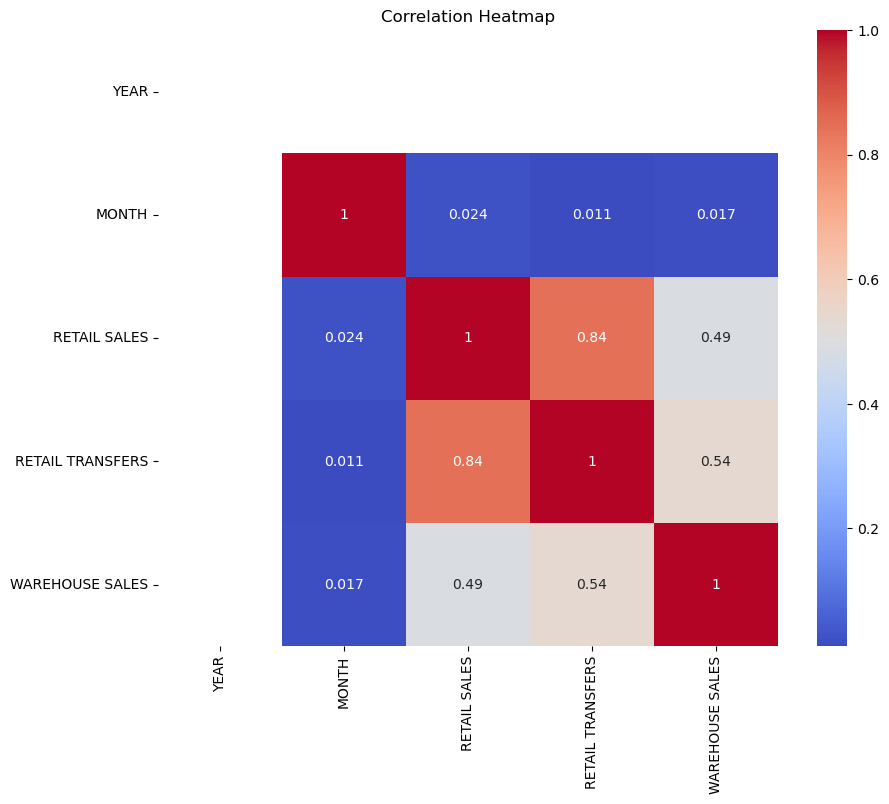

In [12]:
plt.figure(figsize=(10,8))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [17]:
print(df_numeric.columns.tolist())

['YEAR', 'MONTH', 'RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES']


In [20]:
from sklearn.model_selection import train_test_split

target_col = "WAREHOUSE SALES"

X = df_numeric.drop(columns=[target_col])
y = df_numeric[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
df = df.dropna()

In [23]:
target_col = "WAREHOUSE SALES"

X = df.drop(columns=[target_col])
y = df[target_col]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
target_col = "WAREHOUSE SALES"

X = df.drop(columns=[target_col])
y = df[target_col]

In [30]:
['YEAR', 'MONTH', 'RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES',
 'ITEM DESCRIPTION', 'ITEM CODE', 'SUPPLIER', 'ITEM TYPE']

['YEAR',
 'MONTH',
 'RETAIL SALES',
 'RETAIL TRANSFERS',
 'WAREHOUSE SALES',
 'ITEM DESCRIPTION',
 'ITEM CODE',
 'SUPPLIER',
 'ITEM TYPE']

In [31]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
df.columns

Index(['YEAR', 'MONTH', 'SUPPLIER', 'ITEM CODE', 'ITEM DESCRIPTION',
       'ITEM TYPE', 'RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES'],
      dtype='str')

In [34]:
df = df.dropna()

In [35]:
targets = ['RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES']

In [36]:
X = df.drop(columns=targets)

y = df['RETAIL SALES']   # choose one target first

In [51]:
X = df[['YEAR', 'MONTH', 'ITEM TYPE', 'SUPPLIER']]

In [52]:
print(df.columns)
print(df.shape)
df.head()

Index(['YEAR', 'MONTH', 'SUPPLIER', 'ITEM CODE', 'ITEM DESCRIPTION',
       'ITEM TYPE', 'RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES'],
      dtype='str')
(29967, 9)


,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.0
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.0
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.0
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.0
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.0


In [53]:
features = ['YEAR', 'MONTH', 'ITEM TYPE', 'SUPPLIER']
target = 'RETAIL SALES'

X = df[features]
y = df[target]

In [54]:
X = pd.get_dummies(X, drop_first=True)

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [56]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [57]:
y_pred = model.predict(X_test)

In [58]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

MAE: 8.136993440055782
RMSE: 26.192951714306
R2: 0.11616277769716532


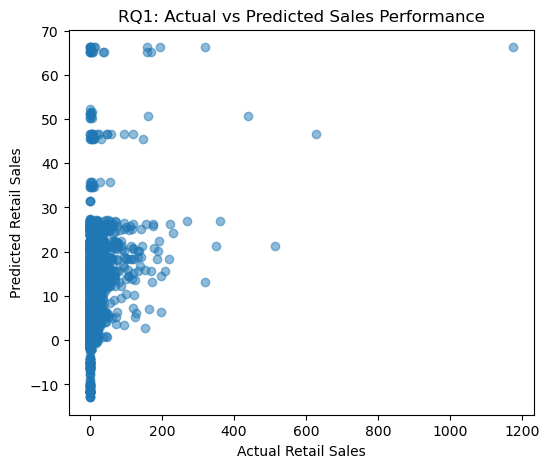

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Retail Sales")
plt.ylabel("Predicted Retail Sales")
plt.title("RQ1: Actual vs Predicted Sales Performance")
plt.show()

In [60]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.to_csv("rq1_results.csv", index=False)
results.head()

,Actual,Predicted
21325,3.22,18.319396
24434,0.50,2.981666
11855,0.00,6.458977
20144,0.85,3.476571
15529,0.00,2.505071


In [61]:
import joblib

joblib.dump(model, "sales_model.pkl")

['sales_model.pkl']